In [1]:

import numpy as np
import json
from pathlib import Path
from sklearn.manifold import Isomap
import matplotlib.pyplot as plt

base_dir = Path("../exp_results/setup1")
def load_trajectories(opt_name):
    opt_dir = base_dir / opt_name
    trajs = {}

    # === Основная фаза обучения ===
    traj_path = opt_dir / f"weight_trajectory_{opt_name}.npy"
    if traj_path.exists():
        trajs["train"] = np.load(traj_path)

    # === Фаза GD для сглаживания ===
    gd_path = opt_dir / "gd" / "gd_weight_trajectory.npy"
    if gd_path.exists():
        trajs["gd"] = np.load(gd_path)

    # === Исследование долины ===
    valley_path = opt_dir / "valley" / "valley_weight_trajectory.npy"
    if valley_path.exists():
        trajs["valley"] = np.load(valley_path)

    return trajs



In [2]:
optimizers = ["sgd", "signsgd", "rmsprop", "muon", "adam"]

start_points = {}

for opt in optimizers:
    trajs = load_trajectories(opt)
    if "train" in trajs:
        start_points[opt] = trajs["train"][0].flatten()


valley (102, 386)


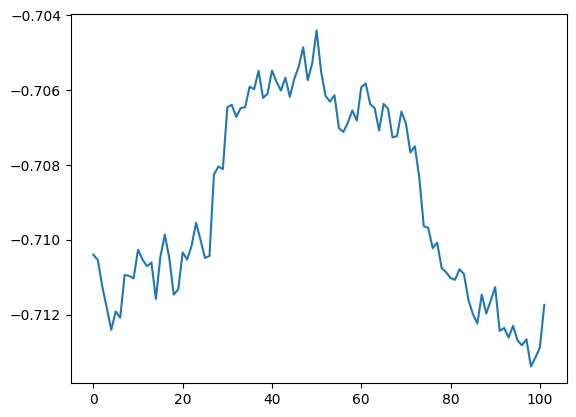

In [11]:
start_idx = 100; end_idx = 101
traj_param = []
# filter_ = ['train', 'gd', 'valley']
filter_ = ['valley']
for key, value in trajs.items():
    if key in filter_:
        print(key , value.shape)
        traj_param+= list(value[:,start_idx:end_idx])
plt.plot(traj_param)    
plt.show()

In [38]:
# Попарные евклидовы расстояния
for i, o1 in enumerate(optimizers):
    for o2 in optimizers[i+1:]:
        dist = np.linalg.norm(start_points[o1] - start_points[o2])
        print(f"Δ(start {o1}, {o2}) = {dist:.6e}")

Δ(start sgd, signsgd) = 0.000000e+00
Δ(start sgd, rmsprop) = 0.000000e+00
Δ(start sgd, muon) = 0.000000e+00
Δ(start sgd, adam) = 0.000000e+00
Δ(start signsgd, rmsprop) = 0.000000e+00
Δ(start signsgd, muon) = 0.000000e+00
Δ(start signsgd, adam) = 0.000000e+00
Δ(start rmsprop, muon) = 0.000000e+00
Δ(start rmsprop, adam) = 0.000000e+00
Δ(start muon, adam) = 0.000000e+00


sgd: ключи в loss_trajectory -> ['train_losses', 'val_losses', 'train_accs', 'val_accs', 'train_steps']
signsgd: ключи в loss_trajectory -> ['train_losses', 'val_losses', 'train_accs', 'val_accs', 'train_steps']
rmsprop: ключи в loss_trajectory -> ['train_losses', 'val_losses', 'train_accs', 'val_accs', 'train_steps']
muon: ключи в loss_trajectory -> ['train_losses', 'val_losses', 'train_accs', 'val_accs', 'train_steps']
adam: ключи в loss_trajectory -> ['train_losses', 'val_losses', 'train_accs', 'val_accs', 'train_steps']


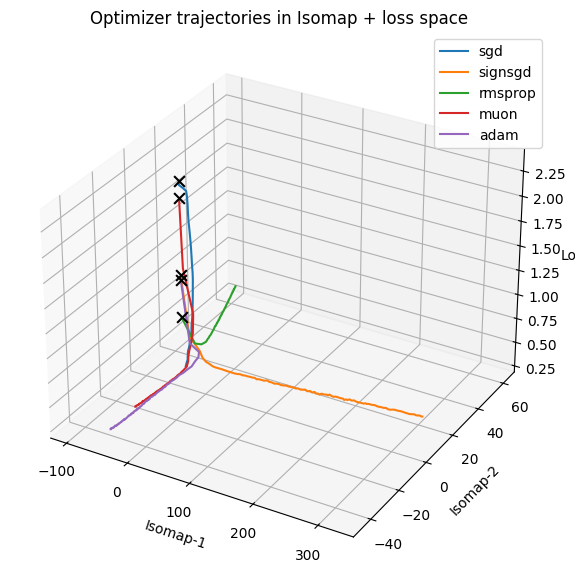

In [12]:
import numpy as np
import json
from pathlib import Path
from sklearn.manifold import Isomap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

base_dir = Path("../exp_results/setup1")
optimizers = ["sgd", "signsgd", "rmsprop", "muon", "adam"]

def load_trajectories(opt_name):
    opt_dir = base_dir / opt_name
    trajs = {}

    traj_path = opt_dir / f"weight_trajectory_{opt_name}.npy"
    if traj_path.exists():
        trajs["train"] = np.load(traj_path)

    gd_path = opt_dir / "gd" / "grad_norms_gd.npy"
    if gd_path.exists():
        trajs["gd"] = np.load(gd_path)

    valley_path = opt_dir / "valley" / "valley_weight_trajectory.npy"
    if valley_path.exists():
        trajs["valley"] = np.load(valley_path)

    return trajs

def load_loss(opt_name):
    opt_dir = base_dir / opt_name
    loss_path = opt_dir / f"loss_trajectory_{opt_name}.npz"
    if loss_path.exists():
        data = np.load(loss_path)
        # Посмотрим, какие ключи внутри
        keys = list(data.keys())
        print(f"{opt_name}: ключи в loss_trajectory -> {keys}")
        # Берём первый массив (или "loss" если есть)
        if "loss" in keys:
            return data["loss"]
        else:
            return data[keys[0]]
    else:
        log_path = opt_dir / f"logs_{opt_name}.json"
        if log_path.exists():
            with open(log_path) as f:
                logs = json.load(f)
            # ищем поле, где лежит история лосса
            for k in ["loss_history", "loss", "train_loss"]:
                if k in logs:
                    return np.array(logs[k])
    return None


# === 1️⃣ Сбор всех точек ===
points, losses, labels = [], [], []
for opt in optimizers:
    trajs = load_trajectories(opt)
    loss = load_loss(opt)
    if not trajs:
        print(f"⚠️ {opt}: нет траекторий, пропускаем")
        continue

    # используем только train-часть для Isomap (иначе разная размерность)
    if "train" not in trajs:
        print(f"⚠️ {opt}: нет train фазы, пропускаем")
        continue

    traj = trajs["train"]
    n = traj.shape[0]
    points.append(traj.reshape(n, -1))
    if loss is not None and len(loss) >= n:
        losses.append(loss[:n])
    else:
        losses.append(np.linspace(1, 0, n))
    labels += [opt] * n

points = np.concatenate(points, axis=0)
losses = np.concatenate(losses, axis=0)

# === 2️⃣ Isomap ===
iso = Isomap(n_neighbors=10, n_components=2)
points_2d = iso.fit_transform(points)
points_3d = np.column_stack([points_2d, losses])

# === 3️⃣ Визуализация ===
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

offset = 0
for opt in optimizers:
    trajs = load_trajectories(opt)
    if not trajs or "train" not in trajs:
        continue
    n = trajs["train"].shape[0]
    segment = points_3d[offset:offset+n]
    ax.plot(segment[:,0], segment[:,1], segment[:,2], label=opt)
    ax.scatter(segment[0,0], segment[0,1], segment[0,2], c='black', marker='x', s=60)
    offset += n

ax.set_xlabel("Isomap-1")
ax.set_ylabel("Isomap-2")
ax.set_zlabel("Loss")
ax.set_title("Optimizer trajectories in Isomap + loss space")
ax.legend()
plt.show()


In [13]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, dissimilarity='euclidean', random_state=42)
points_2d_euc = mds.fit_transform(points)
points_3d_euc = np.column_stack([points_2d_euc, losses])


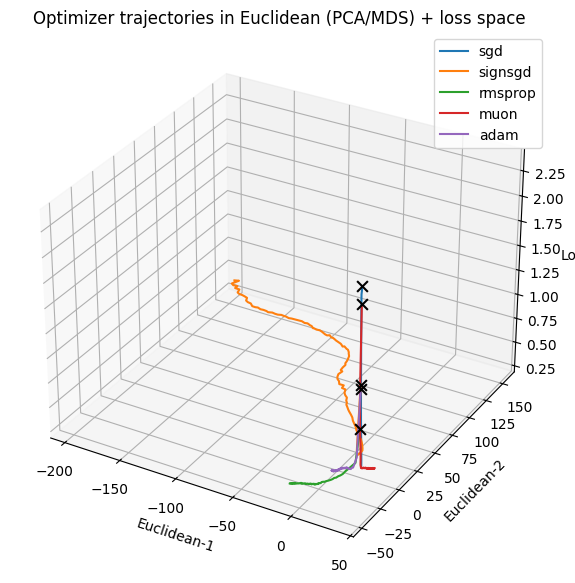

In [14]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

offset = 0
for opt in optimizers:
    trajs = load_trajectories(opt)
    if not trajs or "train" not in trajs:
        continue
    n = trajs["train"].shape[0]
    segment = points_3d_euc[offset:offset+n]
    ax.plot(segment[:,0], segment[:,1], segment[:,2], label=opt)
    ax.scatter(segment[0,0], segment[0,1], segment[0,2], c='black', marker='x', s=60)
    offset += n

ax.set_xlabel("Euclidean-1")
ax.set_ylabel("Euclidean-2")
ax.set_zlabel("Loss")
ax.set_title("Optimizer trajectories in Euclidean (PCA/MDS) + loss space")
ax.legend()
plt.show()


## ОБъединим все фазы 

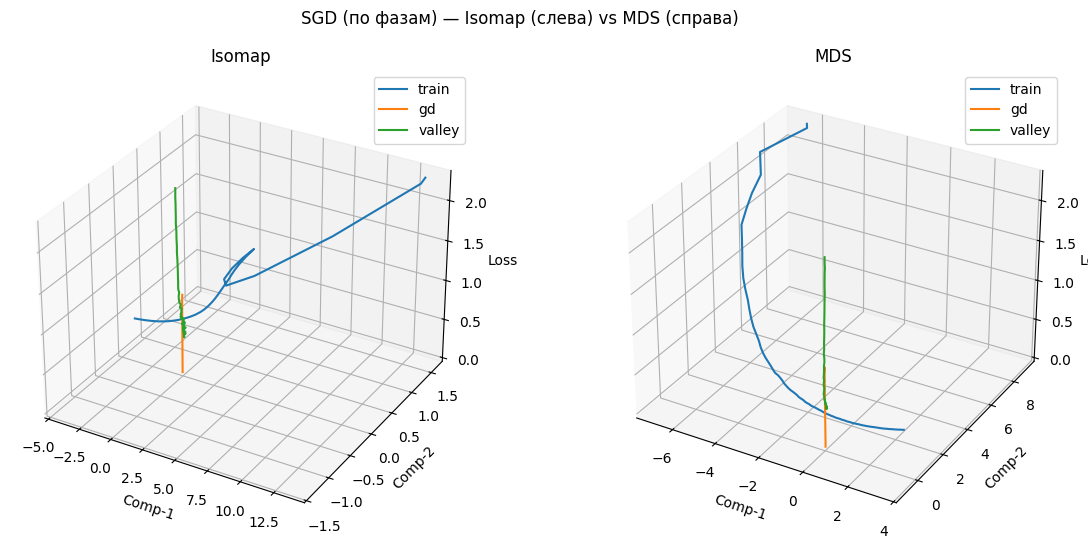

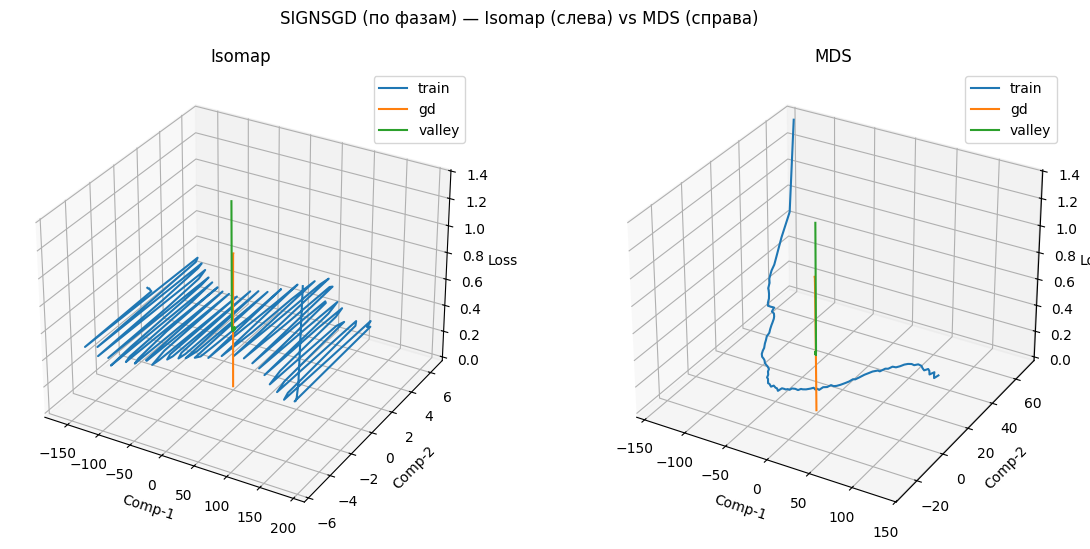

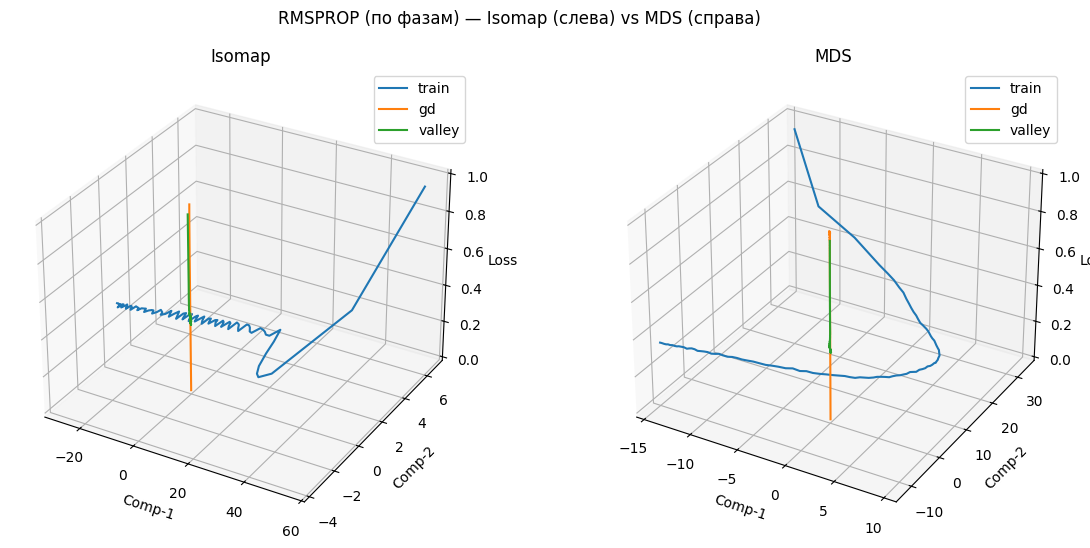

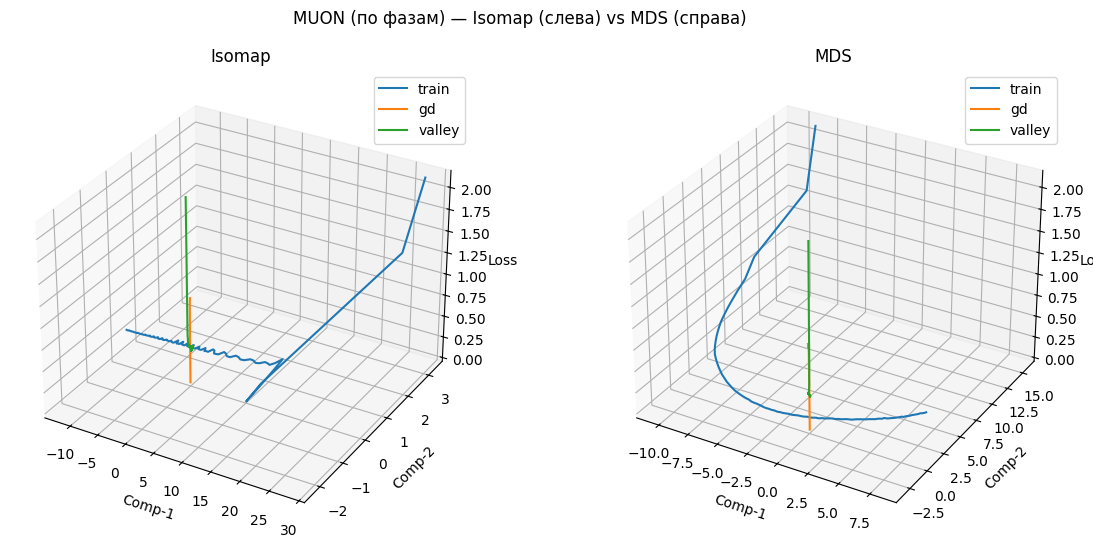

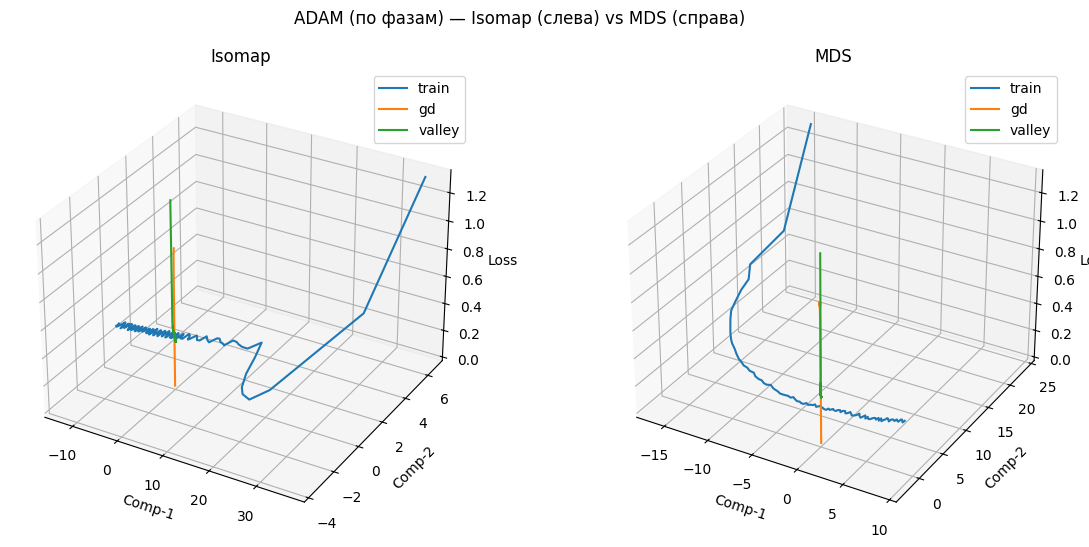

KeyboardInterrupt: 

In [15]:
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import Isomap, MDS

# === пути и оптимайзеры ===
base_dir = Path("../exp_results/setup1")
optimizers = ["sgd", "signsgd", "rmsprop", "muon", "adam"]


# === загрузка траекторий ===
def load_trajectories(opt_name):
    opt_dir = base_dir / opt_name
    trajs = {}

    traj_path = opt_dir / f"weight_trajectory_{opt_name}.npy"
    if traj_path.exists():
        trajs["train"] = np.load(traj_path)

    gd_path = opt_dir / "gd" / "gd_weight_trajectory.npy"
    if gd_path.exists():
        data = np.load(gd_path)
        if data.ndim == 2:
            trajs["gd"] = data

    valley_path = opt_dir / "valley" / "valley_weight_trajectory.npy"
    if valley_path.exists():
        trajs["valley"] = np.load(valley_path)
    return trajs


# === загрузка лоссов ===
def load_loss(opt_name):
    opt_dir = base_dir / opt_name
    loss_path = opt_dir / f"loss_trajectory_{opt_name}.npz"
    if loss_path.exists():
        data = np.load(loss_path)
        keys = list(data.keys())
        if "loss" in keys:
            return data["loss"]
        else:
            return data[keys[0]]
    return None


# === утилита для построения 3D-графиков ===
def plot_3d_comparison(traj_dict, losses_dict, title_prefix=""):
    fig = plt.figure(figsize=(14, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122, projection='3d')
    fig.suptitle(f"{title_prefix} — Isomap (слева) vs MDS (справа)", fontsize=12)

    for phase, traj in traj_dict.items():
        if traj.shape[0] < 3:  # пропускаем слишком короткие
            continue
        n = traj.shape[0]
        loss = losses_dict.get(phase, np.linspace(1, 0, n))

        iso = Isomap(n_neighbors=8, n_components=2)
        mds = MDS(n_components=2, dissimilarity='euclidean', random_state=42)

        emb_iso = iso.fit_transform(traj)
        emb_mds = mds.fit_transform(traj)

        seg_iso = np.column_stack([emb_iso, loss])
        seg_mds = np.column_stack([emb_mds, loss])

        ax1.plot(seg_iso[:, 0], seg_iso[:, 1], seg_iso[:, 2], label=phase)
        ax2.plot(seg_mds[:, 0], seg_mds[:, 1], seg_mds[:, 2], label=phase)

    for ax, label in zip([ax1, ax2], ["Isomap", "MDS"]):
        ax.set_xlabel("Comp-1")
        ax.set_ylabel("Comp-2")
        ax.set_zlabel("Loss")
        ax.set_title(label)
        ax.legend()
    plt.show()


# === 1️⃣ Отдельные фазы для каждого оптимайзера ===
for opt in optimizers:
    trajs = load_trajectories(opt)
    if not trajs:
        continue
    losses = {}
    loss_full = load_loss(opt)
    for phase, traj in trajs.items():
        if loss_full is not None and len(loss_full) >= len(traj):
            losses[phase] = loss_full[: len(traj)]
    plot_3d_comparison(trajs, losses, title_prefix=f"{opt.upper()} (по фазам)")


# === 2️⃣ Конкатенированные фазы ===
def plot_concatenated_3d(opt_name):
    trajs = load_trajectories(opt_name)
    if not trajs:
        return
    all_traj = np.concatenate([v for v in trajs.values() if v.ndim == 2], axis=0)
    phase_names = list(trajs.keys())
    phase_lengths = [len(v) for v in trajs.values() if v.ndim == 2]
    loss = load_loss(opt_name)
    if loss is None or len(loss) < len(all_traj):
        loss = np.linspace(1, 0, len(all_traj))

    iso = Isomap(n_neighbors=8, n_components=2)
    mds = MDS(n_components=2, dissimilarity='euclidean', random_state=42)

    emb_iso = iso.fit_transform(all_traj)
    emb_mds = mds.fit_transform(all_traj)
    emb_iso = np.column_stack([emb_iso, loss])
    emb_mds = np.column_stack([emb_mds, loss])

    fig = plt.figure(figsize=(14, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122, projection='3d')
    fig.suptitle(f"{opt_name.upper()} — конкатенированные фазы", fontsize=12)

    offset = 0
    for i, name in enumerate(phase_names):
        n = phase_lengths[i]
        ax1.plot(emb_iso[offset:offset+n, 0], emb_iso[offset:offset+n, 1], emb_iso[offset:offset+n, 2], label=name)
        ax2.plot(emb_mds[offset:offset+n, 0], emb_mds[offset:offset+n, 1], emb_mds[offset:offset+n, 2], label=name)
        offset += n

    for ax, label in zip([ax1, ax2], ["Isomap", "MDS"]):
        ax.set_xlabel("Comp-1")
        ax.set_ylabel("Comp-2")
        ax.set_zlabel("Loss")
        ax.set_title(label)
        ax.legend()
    plt.show()


for opt in optimizers:
    plot_concatenated_3d(opt)


# === 3️⃣ Фаза VALLEY по оптимайзерам ===
def plot_valley_all_opts_3d():
    fig = plt.figure(figsize=(14, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122, projection='3d')
    fig.suptitle("Фаза VALLEY — сравнение оптимайзаторов", fontsize=12)

    for opt in optimizers:
        trajs = load_trajectories(opt)
        if "valley" not in trajs:
            continue
        traj = trajs["valley"]
        loss = load_loss(opt)
        if loss is None or len(loss) < len(traj):
            loss = np.linspace(1, 0, len(traj))

        iso = Isomap(n_neighbors=8, n_components=2)
        mds = MDS(n_components=2, dissimilarity='euclidean', random_state=42)
        emb_iso = np.column_stack([iso.fit_transform(traj), loss])
        emb_mds = np.column_stack([mds.fit_transform(traj), loss])

        ax1.plot(emb_iso[:, 0], emb_iso[:, 1], emb_iso[:, 2], label=opt)
        ax2.plot(emb_mds[:, 0], emb_mds[:, 1], emb_mds[:, 2], label=opt)

    for ax, label in zip([ax1, ax2], ["Isomap", "MDS"]):
        ax.set_xlabel("Comp-1")
        ax.set_ylabel("Comp-2")
        ax.set_zlabel("Loss")
        ax.set_title(label)
        ax.legend()
    plt.show()


plot_valley_all_opts_3d()


⚠️ sgd/gd: shape=(1000,) — пропускаем (не 2D)


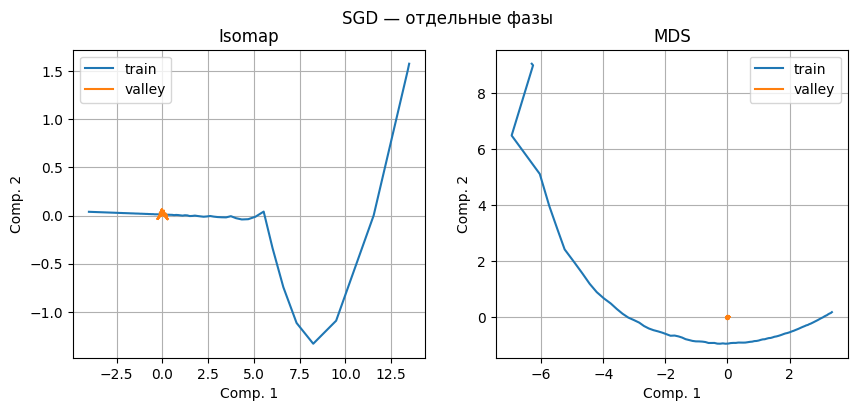

⚠️ signsgd/gd: shape=(1000,) — пропускаем (не 2D)


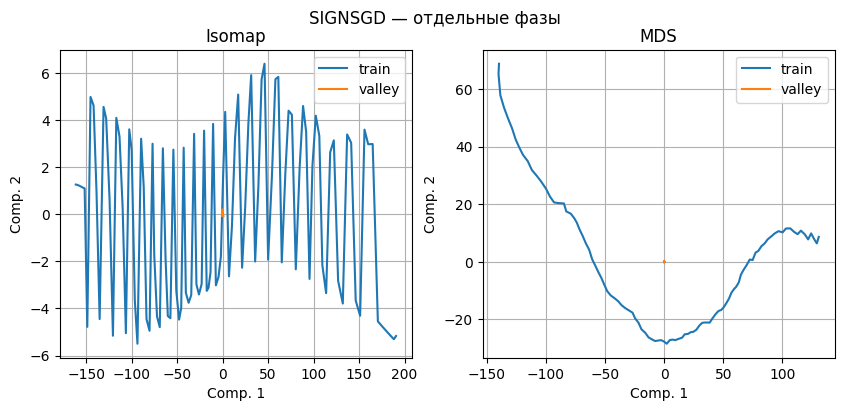

⚠️ rmsprop/gd: shape=(1000,) — пропускаем (не 2D)


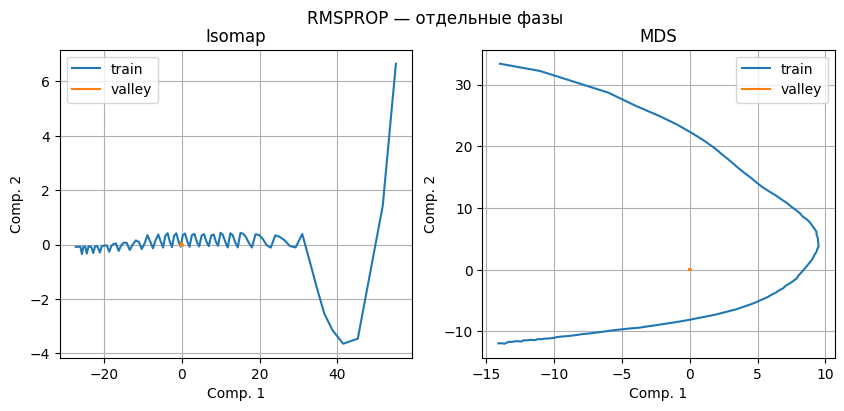

⚠️ muon/gd: shape=(1000,) — пропускаем (не 2D)


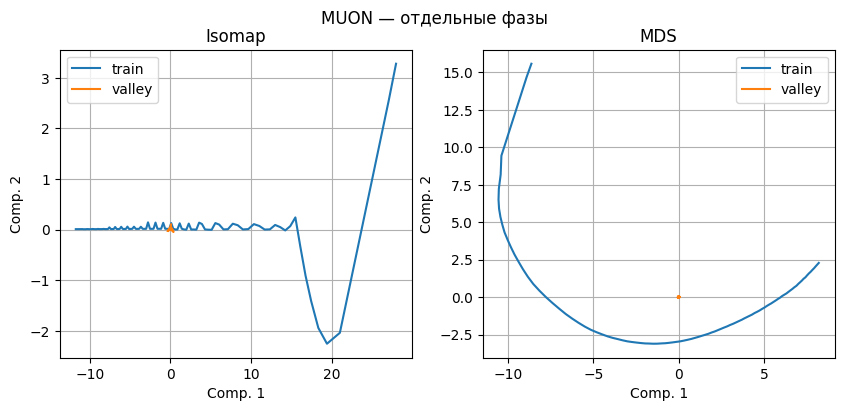

⚠️ adam/gd: shape=(1000,) — пропускаем (не 2D)


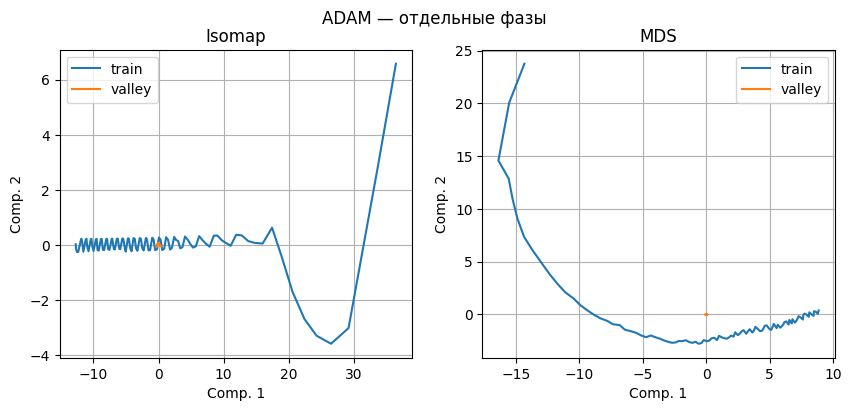

In [52]:
# === 2️⃣ Конкатенированные фазы ===
for opt in optimizers:
    print(f"\n=== {opt.upper()} — конкатенированные фазы ===")
    trajs = load_trajectories(opt)
    if not trajs:
        print("⚠️ Нет данных, пропускаем")
        continue
    plot_concatenated(opt, trajs)



=== SGD — конкатенированные фазы ===


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 1 dimension(s)